In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Chargement des données
df = pd.read_csv("cve_anssi_enriched.csv")

# Nettoyage rapide
df = df.dropna(subset=["cvss", "epss"])
df = df[df["cvss"] != "Non disponible"]
df = df[df["epss"] != "Non disponible"]
df["cvss"] = df["cvss"].astype(float)
df["epss"] = df["epss"].astype(float)

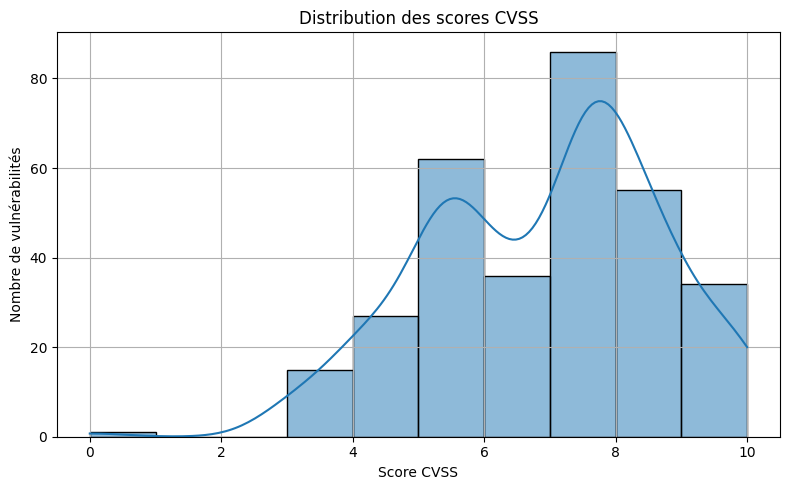

In [7]:
# Histogramme des scores CVSS
plt.figure(figsize=(8, 5))
sns.histplot(df["cvss"], bins=10, kde=True)
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.grid(True)
plt.tight_layout()
plt.savefig("cvss_distribution.png")
plt.show()

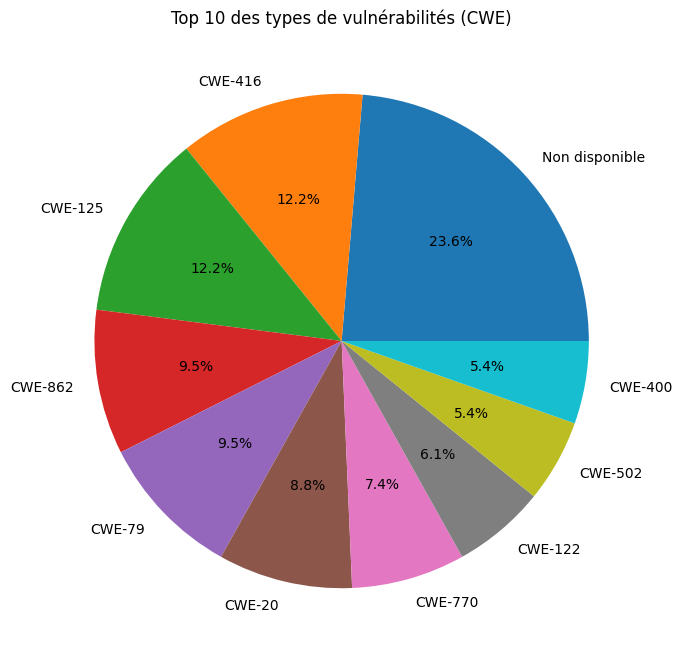

In [8]:
# Diagramme circulaire des types CWE
top_cwe = df["cwe"].value_counts().head(10)
plt.figure(figsize=(7, 7))
top_cwe.plot.pie(autopct="%1.1f%%")
plt.title("Top 10 des types de vulnérabilités (CWE)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("cwe_pie.png")
plt.show()

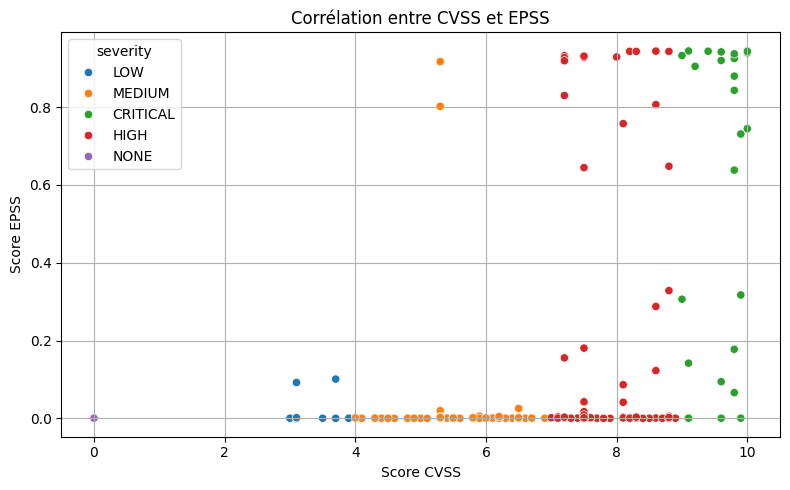

In [9]:
# Nuage de points CVSS vs EPSS
plt.figure(figsize=(8, 5))
sns.scatterplot(x="cvss", y="epss", data=df, hue="severity")
plt.title("Corrélation entre CVSS et EPSS")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.grid(True)
plt.tight_layout()
plt.savefig("scatter_cvss_epss.png")
plt.show()

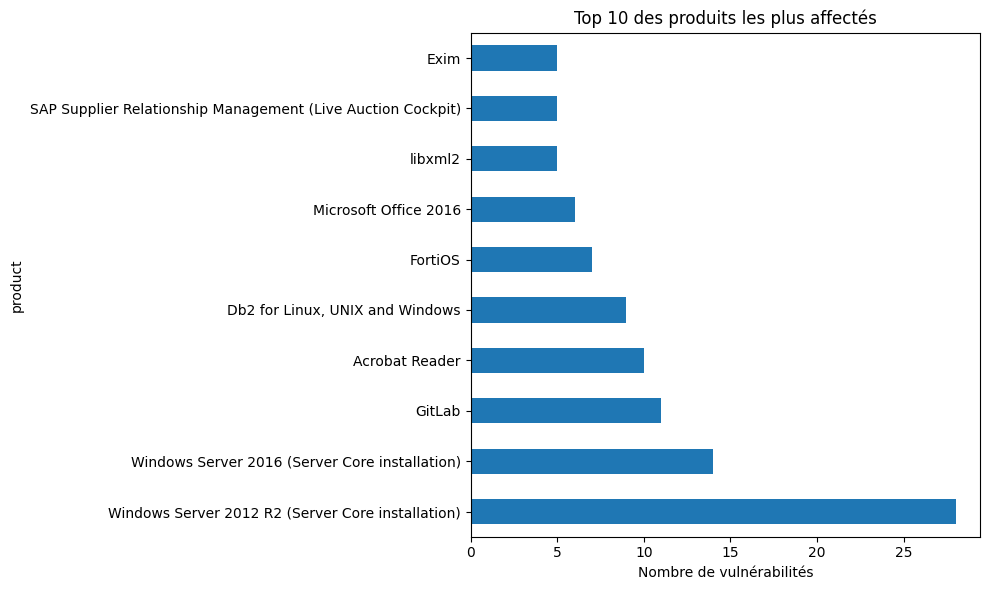

In [10]:
# Produits les plus affectés
plt.figure(figsize=(10, 6))
df["product"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 des produits les plus affectés")
plt.xlabel("Nombre de vulnérabilités")
plt.tight_layout()
plt.savefig("top_products.png")
plt.show()

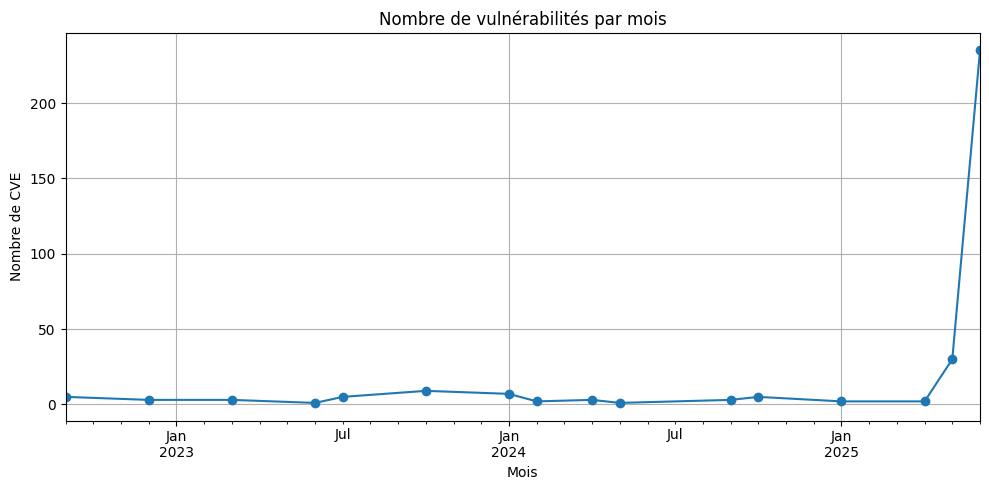

In [11]:
# Évolution temporelle
df["date"] = pd.to_datetime(df["date"])
df_by_month = df.groupby(df["date"].dt.to_period("M")).size()
df_by_month.plot(kind="line", marker="o", figsize=(10, 5))
plt.title("Nombre de vulnérabilités par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de CVE")
plt.grid(True)
plt.tight_layout()
plt.savefig("timeline.png")
plt.show()